# Week 12 Part1 Vision-Based People Counter

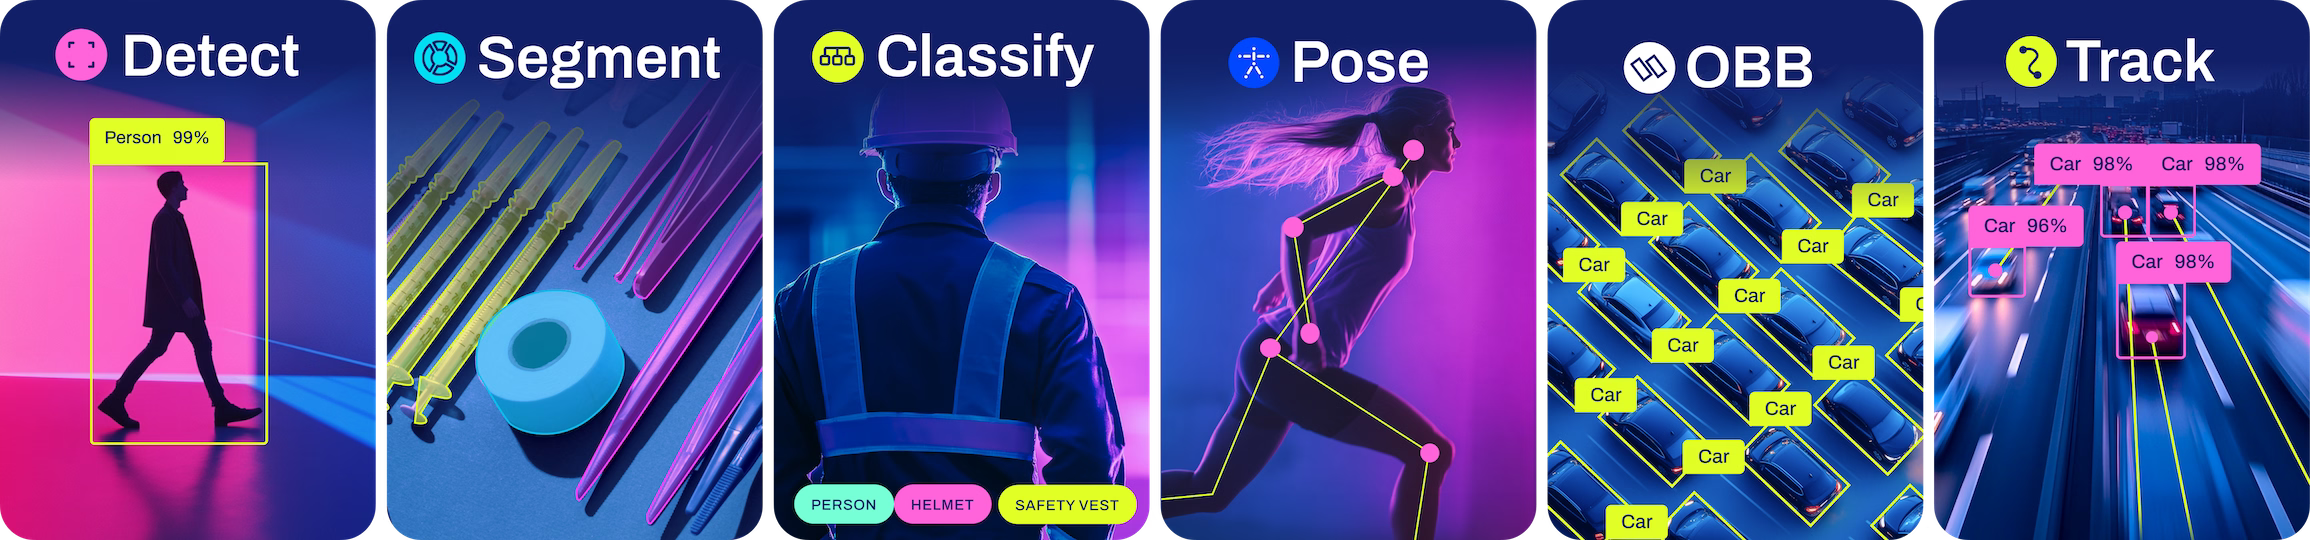

https://docs.ultralytics.com/tasks/

In [5]:
from collections import defaultdict
import cv2
import numpy as np
from ultralytics import YOLO

# Initialize model and video

# Load the YOLO segmentation Model 
model = YOLO(r"C:\Users\jinny\Desktop\cv\YOLO\yolo11n-seg.pt")

# List of video sources
video_path = [0,r"C:\Users\jinny\Desktop\cv\VDO\background video_people_walking.mp4"]
# Video capture sues list of video part
cap = cv2.VideoCapture(video_path[1])
# Tracking and counting variables
# Tracking historu store x, y
track_history = defaultdict(lambda: [])
# Count inds store ID that have already crossed the crossed the line
count_ind = set()
# The total person counter
person_count = 0

# While loop read video frame by frame 
while cap.isOpened():
    # Read frame
    ret, frame = cap.read()
    if not ret:
        break
    # Get frame dimension h, w
    h,w = frame.shape[:2]
    # Set the horizontal counting line position
    line_y = h-250

    # Run tracking + segmentation
    result = model.track(frame, persist=True, conf = 0.3)[0]

    # Draw counting line
    cv2.line(frame,(0, line_y),(w,line_y),(0,0,255),2)

    # Check if there are active boxes being tracked
    if result.boxes and result.boxes.is_track:

        # Get coordinates (x, y, w, h)
        boxes = result.boxes.xywh.cpu()
        # Get unique tracking IDs and Class IDs
        track_ids = result.boxes.id.int().tolist()
        classes = result.boxes.cls.int().cpu().tolist()
        # Draw segmentation masks
        # if result.masks is not None:
        frame = result.plot() # includes mask

        for box, track_id, cls in zip(boxes, track_ids, classes):

            # Only process if the detected clsses is person (class 0 of COCO)
            if cls != 0:
                continue
            # Extract the center y coordinate of the person    
            x, y, w, h = box
            center_y = float(y + h/2)
            # Udate the movement history for the ID
            track = track_history[track_id]
            track.append((float(x), center_y))
            # Limit the last 30 frame 
            if len(track) > 30:
                track.pop(0)


            # Check if the persion just acrossed the line:
            # Previous Y < Line < Current Y
            if len(track) >= 2:
                prev_y = track[-2][1]

                # If person meved from abrove line to below line
                if prev_y < line_y and center_y >= line_y:

                    # Check if program haven't counted this ID yet
                    if track_id not in count_ind:
                        person_count += 1
                        count_ind.add(track_id)

            # draw trajectory
            point = np.array(track, dtype=np.int32).reshape((-1, 1, 2))
            cv2.polylines(frame, [point], False, (0, 255, 0), 3)


    # Show count
    cv2.putText(frame,
                f"Count: {person_count}",
                (40, 70),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.5,
                (0, 0, 255),
                3
        )
    # Show the display windows
    cv2.imshow("Person Counter", frame)
  
    # Press 'q' to exit the loop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


# Release video capture and close all windows
cap.release()
cv2.destroyAllWindows()



0: 384x640 19 persons, 54.9ms
Speed: 14.7ms preprocess, 54.9ms inference, 16.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 19 persons, 15.8ms
Speed: 2.0ms preprocess, 15.8ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 20 persons, 23.9ms
Speed: 1.8ms preprocess, 23.9ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 19 persons, 14.8ms
Speed: 1.5ms preprocess, 14.8ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 20 persons, 13.2ms
Speed: 1.6ms preprocess, 13.2ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 20 persons, 16.2ms
Speed: 2.9ms preprocess, 16.2ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 20 persons, 15.8ms
Speed: 1.7ms preprocess, 15.8ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 persons, 14.7ms
Speed: 2.1ms preprocess, 14.7ms inference, 2.8ms postprocess per image 